# Automated Warehouse Feasibility Analysis

This notebook evaluates which spare parts are suitable candidates for storage in the automated warehouse.

The analysis uses the technical constraints of the automated tray warehouse and the operational characteristics of the spare-parts population.

The objective is to evaluate:
- dimensional feasibility
- volume feasibility
- movement-based automation priority
- automated-storage coverage
- excluded-item reasons
- candidate items for tray-configuration analysis

This notebook does not optimise tray configuration.  
Tray subdivision and compartment allocation are handled in the following notebook.

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/automated_warehouse")
OUTPUT_DIR.mkdir(exist_ok=True)

POWERBI_INPUT_DIR = Path("../outputs/powerbi_operational")

fact_inventory_status = pd.read_csv(
    POWERBI_INPUT_DIR / "fact_inventory_status.csv"
)

dim_parts = pd.read_csv(
    POWERBI_INPUT_DIR / "dim_parts.csv"
)

## Feasibility Dataset

The feasibility dataset combines part master data with current inventory status.

The analysis uses:
- movement classification
- stock quantity
- available quantity
- physical dimensions
- occupied volume
- UDC/container type
- inventory value
- demand behaviour

The objective is to evaluate whether each item is operationally and physically suitable for automated storage.

In [18]:
automation_feasibility = (
    fact_inventory_status
    .merge(
        dim_parts[
            [
                "Part_ID",
                "Part_Name",
                "Equipment_Family",
                "Equipment_Model",
                "Demand_Profile",
                "Storage_Type",
                "Lifecycle_Status",
                "Dim_X_mm",
                "Dim_Y_mm",
                "Dim_Z_mm",
                "Max_Dimension_mm"
            ]
        ],
        on="Part_ID",
        how="left"
    )
)

automation_feasibility.head()

,Part_ID,On_Hand_Qty,On_Order_Qty,Allocated_Qty,Available_Qty,Avg_Weekly_Demand,Demand_SD,Demand_CV,Nonzero_Demand_Weeks,XYZ_Class,Lead_Time_Weeks,Safety_Stock_Qty,Reorder_Point_Qty,Suggested_Replenishment_Qty,Planner_Exception_Flag,Manual_Location,UDC_Type,Unit_Cost_EUR,ABC_Class,Movement_Class,Movement_Lines_36M,Criticality,Supplier_ID,Supplier_Region,Part_Category,Unit_Volume_cm3,Stock_Qty,Max_Stock_Qty,Stock_Managed,Estimated_Inventory_Value_EUR,Below_Reorder_Point,Stock_Coverage_Weeks,Total_Occupied_Volume_cm3,Part_Name,Equipment_Family,Equipment_Model,Demand_Profile,Storage_Type,Lifecycle_Status,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Max_Dimension_mm
0,TC-CON-0343,46,0,9,37,3.000000,3.270592,1.090197,102,Y,1.4,18,35,0,False,R-I38,VER,40.87,A,A+,473,Medium,SUP-015,EU,Consumables & service kits,72293,46,48,1,1512.19,False,12.333333,3325478,Basic Line TC Grease Cartridge,Tyre Changer,Basic Line TC,frequent,Bin,Active,1543,689,68,1543
1,VL-CON-0336,23,0,7,16,3.852564,2.248453,0.583625,139,X,1.0,13,22,22,True,R-B17,D,29.16,A,A+,395,Medium,SUP-004,EU,Consumables & service kits,470,23,38,1,466.56,True,4.153078,10810,Scissor Lift Air Filter,Vehicle Lift,Scissor Lift,frequent,Bin,Active,258,91,20,258
2,TC-CON-0329,23,0,5,18,3.365385,2.032277,0.603877,135,X,1.3,13,22,21,True,R-E25,B,43.54,A,A+,313,Medium,SUP-018,EU,Consumables & service kits,77,23,39,1,783.72,True,5.348571,1771,A2024 LL Air Filter,Tyre Changer,A2024 LL,frequent,Bin,Active,61,30,42,61
3,WA-CON-0631,16,7,4,19,3.602564,2.118062,0.587932,141,X,1.3,15,21,13,True,R-F76,D,26.96,A,A+,231,Medium,SUP-020,EU,Consumables & service kits,2480,16,32,1,512.24,True,5.274021,39680,Exact Precision Lubrication Kit,Wheel Aligner,Exact Precision,frequent,Bin,Active,177,98,143,177
4,TC-CON-0171,17,0,2,15,2.929487,3.428744,1.170425,95,Y,1.0,6,12,0,False,R-L86,B,40.68,A,A+,227,Medium,SUP-003,EU,Consumables & service kits,820,17,20,1,610.20,False,5.120350,13940,Basic Line TC Air Filter,Tyre Changer,Basic Line TC,frequent,Bin,Active,135,132,46,135


## Automated Warehouse Technology Selection

The selected automated storage solution is a vertical tray-based warehouse system designed for spare-parts storage and picking operations.

This type of warehouse was selected because the spare-parts environment is characterised by:
- high SKU variety
- uneven movement concentration
- relatively compact items
- variable item dimensions
- high accessibility requirements
- limited available warehouse space

A vertical automated tray system improves:
- storage density
- picking accessibility
- warehouse-space utilisation
- operator efficiency
- inventory visibility

while reducing:
- manual travel distance
- low-density storage areas
- inefficient picking operations

The selected warehouse logic uses fixed external tray dimensions with configurable internal compartment layouts, allowing different item categories to be stored within the same automated system.

### Automated Storage System Definition

At this stage, the analysis uses the predefined tray envelope to evaluate whether each item can physically enter the automated storage system.

The tray envelope defines:
- useful tray width
- useful tray depth
- recommended item height
- tray pitch allowance

The total number of trays and final warehouse capacity are dimensioned later, after the automation candidate population has been identified.

In [19]:
AUTO_STORAGE_ENVELOPE = {
    "System": "UR 10 vertical tray warehouse",
    "Tray_Useful_Width_mm": 1611,
    "Tray_Useful_Depth_mm": 807,
    "Tray_Useful_Area_m2": 1.3,
    "Max_Tray_Load_kg": 500,
    "Tray_Pitch_mm": 200,
    "Recommended_Max_Item_Height_mm": 175
}

pd.DataFrame(
    AUTO_STORAGE_ENVELOPE.items(),
    columns=["Parameter", "Value"]
)

,Parameter,Value
0,System,UR 10 vertical tray warehouse
1,Tray_Useful_Width_mm,1611
2,Tray_Useful_Depth_mm,807
3,Tray_Useful_Area_m2,1.3
4,Max_Tray_Load_kg,500
5,Tray_Pitch_mm,200
6,Recommended_Max_Item_Height_mm,175


## Dimensional Feasibility

Items must fit within the useful tray dimensions and remain below the recommended maximum item height.

This step evaluates whether the item dimensions are compatible with automated tray storage before any tray-compartment optimisation is performed.

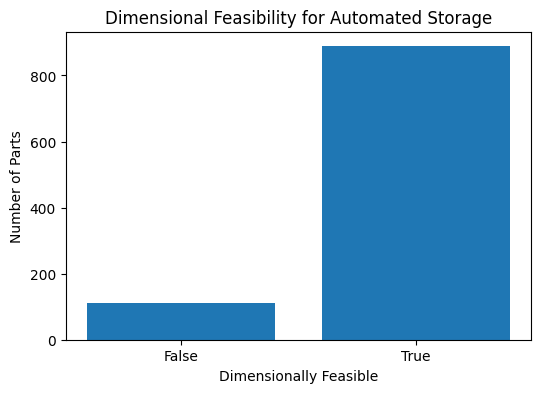

,Dimensionally_Feasible,Parts,Total_Movement_Lines,Total_Occupied_Volume_cm3
0,False,112,286,105219338
1,True,888,6042,35867753


In [20]:
tray_width = AUTO_STORAGE_ENVELOPE["Tray_Useful_Width_mm"]
tray_depth = AUTO_STORAGE_ENVELOPE["Tray_Useful_Depth_mm"]
max_height = AUTO_STORAGE_ENVELOPE["Recommended_Max_Item_Height_mm"]

# item can be rotated within tray footprint
automation_feasibility["Fits_Tray_Footprint"] = (
    (
        (automation_feasibility["Dim_X_mm"] <= tray_width) &
        (automation_feasibility["Dim_Y_mm"] <= tray_depth)
    ) |
    (
        (automation_feasibility["Dim_X_mm"] <= tray_depth) &
        (automation_feasibility["Dim_Y_mm"] <= tray_width)
    )
)

# height compatibility with tray pitch allowance
automation_feasibility["Fits_Height"] = (
    automation_feasibility["Dim_Z_mm"] <= max_height
)

# item must satisfy both footprint and height constraints
automation_feasibility["Dimensionally_Feasible"] = (
    automation_feasibility["Fits_Tray_Footprint"] &
    automation_feasibility["Fits_Height"]
)

dimension_feasibility_summary = (
    automation_feasibility
    .groupby("Dimensionally_Feasible")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Total_Occupied_Volume_cm3=("Total_Occupied_Volume_cm3", "sum")
    )
    .round(2)
    .reset_index()
)

dimensionally_feasible_items = automation_feasibility[
    automation_feasibility["Dimensionally_Feasible"]
]

plt.figure(figsize=(6,4))

plt.bar(
    dimension_feasibility_summary["Dimensionally_Feasible"].astype(str),
    dimension_feasibility_summary["Parts"]
)

plt.xlabel("Dimensionally Feasible")
plt.ylabel("Number of Parts")
plt.title("Dimensional Feasibility for Automated Storage")

plt.show()

dimension_feasibility_summary

## Movement-Based Automation Priority

The automated warehouse should prioritise items that generate frequent movements, because these items benefit most from improved accessibility and reduced manual picking effort.

This section classifies automation priority using movement class.

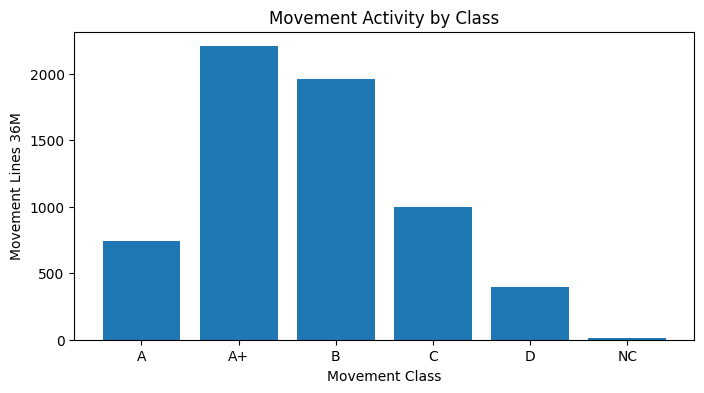

,Movement_Class,Dimensionally_Feasible,Parts,Total_Movement_Lines,Total_Occupied_Volume_cm3
0,A,False,1,109,7756920
1,A,True,8,633,345693
2,A+,True,8,2207,3593676
3,B,False,3,92,3848434
4,B,True,56,1873,3385728
5,C,False,5,24,1772608
6,C,True,162,977,7240902
7,D,False,45,61,47680471
8,D,True,293,336,10166466
9,NC,False,58,0,44160905


In [21]:
# highest operational movement classes
high_priority_movement_classes = ["A+", "A", "B"]

automation_feasibility["Movement_Priority_For_Automation"] = (
    automation_feasibility["Movement_Class"].isin(high_priority_movement_classes)
)

movement_feasibility_summary = (
    automation_feasibility
    .groupby(["Movement_Class", "Dimensionally_Feasible"])
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Total_Occupied_Volume_cm3=("Total_Occupied_Volume_cm3", "sum")
    )
    .round(2)
    .reset_index()
)

movement_plot = (
    automation_feasibility
    .groupby("Movement_Class")
    .agg(
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(8,4))

plt.bar(
    movement_plot["Movement_Class"],
    movement_plot["Total_Movement_Lines"]
)

plt.xlabel("Movement Class")
plt.ylabel("Movement Lines 36M")
plt.title("Movement Activity by Class")

plt.show()

movement_feasibility_summary

## Automated Storage Candidate Logic

Candidate items are selected using combined physical and operational rules.

An item is considered a candidate when:
- it fits the automated tray footprint
- it fits the recommended tray height
- it is stock-managed
- it is not assigned to oversized/manual-only handling categories
- it has either relevant movement activity or compact storage characteristics

This is a feasibility screening step, not the final tray-allocation optimisation.

In [22]:
manual_only_udc = ["arancio", "pallet", "cassone_arancione", "oversize"]

automation_feasibility["Manual_Only_UDC"] = (
    automation_feasibility["UDC_Type"]
    .astype(str)
    .str.lower()
    .isin(manual_only_udc)
)

# median-volume threshold used to identify compact items
compact_item_threshold = (
    automation_feasibility["Unit_Volume_cm3"]
    .quantile(0.50)
)

automation_feasibility["Compact_Item"] = (
    automation_feasibility["Unit_Volume_cm3"] <= compact_item_threshold
)

automation_feasibility["Automation_Candidate"] = (
    automation_feasibility["Dimensionally_Feasible"] &
    (automation_feasibility["Stock_Managed"] == 1) &
    (~automation_feasibility["Manual_Only_UDC"]) &
    (
        automation_feasibility["Movement_Priority_For_Automation"] |
        automation_feasibility["Compact_Item"]
    )
)

candidate_summary = pd.DataFrame({
    "Metric": [
        "Total parts analysed",
        "Dimensionally feasible parts",
        "Automation candidate parts",
        "Candidate movement lines",
        "Candidate occupied volume cm3",
        "Candidate inventory value EUR"
    ],
    "Value": [
        int(automation_feasibility["Part_ID"].nunique()),
        int(automation_feasibility["Dimensionally_Feasible"].sum()),
        int(automation_feasibility["Automation_Candidate"].sum()),
        int(automation_feasibility.loc[
            automation_feasibility["Automation_Candidate"],
            "Movement_Lines_36M"
        ].sum()),
        int(automation_feasibility.loc[
            automation_feasibility["Automation_Candidate"],
            "Total_Occupied_Volume_cm3"
        ].sum()),
        round(
            automation_feasibility.loc[
                automation_feasibility["Automation_Candidate"],
                "Estimated_Inventory_Value_EUR"
            ].sum(),
            2
        )
    ]
})

candidate_summary

,Metric,Value
0,Total parts analysed,1000.00
1,Dimensionally feasible parts,888.00
2,Automation candidate parts,377.00
3,Candidate movement lines,5341.00
4,Candidate occupied volume cm3,8224903.00
5,Candidate inventory value EUR,203613.46


## Automation Coverage

This section evaluates the share of SKUs, movements, inventory value, and occupied volume covered by the candidate automation population.

These indicators help evaluate whether automation candidates represent a meaningful share of warehouse activity.

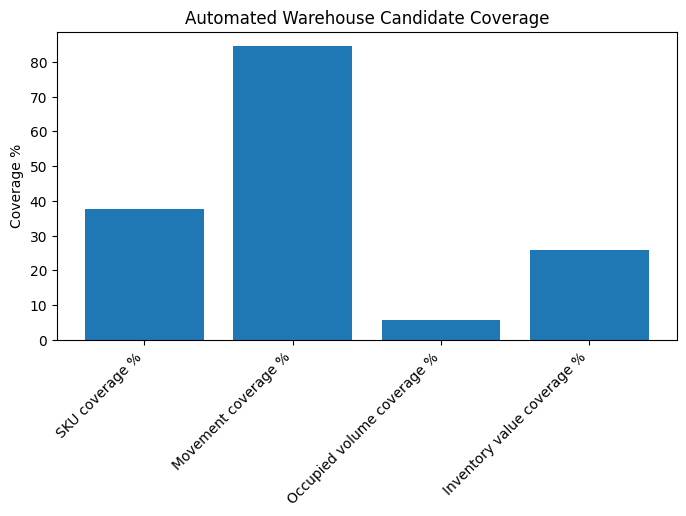

,Coverage_Metric,Value
0,SKU coverage %,37.70
1,Movement coverage %,84.40
2,Occupied volume coverage %,5.83
3,Inventory value coverage %,25.86


In [23]:
total_parts = automation_feasibility["Part_ID"].nunique()
total_movements = automation_feasibility["Movement_Lines_36M"].sum()
total_volume = automation_feasibility["Total_Occupied_Volume_cm3"].sum()
total_value = automation_feasibility["Estimated_Inventory_Value_EUR"].sum()

# combined operational and physical feasibility screening
candidate_data = automation_feasibility[
    automation_feasibility["Automation_Candidate"]
]

automation_coverage = pd.DataFrame({
    "Coverage_Metric": [
        "SKU coverage %",
        "Movement coverage %",
        "Occupied volume coverage %",
        "Inventory value coverage %"
    ],
    "Value": [
        round(candidate_data["Part_ID"].nunique() / total_parts * 100, 2),
        round(candidate_data["Movement_Lines_36M"].sum() / total_movements * 100, 2),
        round(candidate_data["Total_Occupied_Volume_cm3"].sum() / total_volume * 100, 2),
        round(candidate_data["Estimated_Inventory_Value_EUR"].sum() / total_value * 100, 2)
    ]
})

plt.figure(figsize=(8,4))

plt.bar(
    automation_coverage["Coverage_Metric"],
    automation_coverage["Value"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Coverage %")
plt.title("Automated Warehouse Candidate Coverage")

plt.show()

automation_coverage

## Exclusion Reason Analysis

Not all items should be inserted into the automated warehouse.

This section identifies the main reasons why items are excluded from the candidate population.

In [24]:
def assign_exclusion_reason(row):
    if row["Automation_Candidate"]:
        return "Candidate"
    if not row["Fits_Tray_Footprint"]:
        return "Does not fit tray footprint"
    if not row["Fits_Height"]:
        return "Exceeds recommended tray height"
    if row["Manual_Only_UDC"]:
        return "Manual-only / oversized UDC"
    if row["Stock_Managed"] != 1:
        return "Not stock-managed"
    return "Operationally lower automation priority"

automation_feasibility["Automation_Exclusion_Reason"] = (
    automation_feasibility.apply(assign_exclusion_reason, axis=1)
)

exclusion_summary = (
    automation_feasibility
    .groupby("Automation_Exclusion_Reason")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Total_Occupied_Volume_cm3=("Total_Occupied_Volume_cm3", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values("Parts", ascending=False)
)

exclusion_summary

,Automation_Exclusion_Reason,Parts,Total_Movement_Lines,Total_Occupied_Volume_cm3
0,Candidate,377,5341,8224903
4,Not stock-managed,299,215,10176716
5,Operationally lower automation priority,205,482,16083529
2,Exceeds recommended tray height,108,176,91755388
3,Manual-only / oversized UDC,7,4,1382605
1,Does not fit tray footprint,4,110,13463950


## Candidate Items for Tray Configuration

The candidate list is the input for the following tray-configuration optimisation notebook.

At this stage, items are screened for feasibility, but they are not yet assigned to final tray layouts or compartments.

In [25]:
# prioritise high-movement and space-efficient items
automation_candidates = (
    automation_feasibility[
        automation_feasibility["Automation_Candidate"]
    ]
    .sort_values(
        ["Movement_Lines_36M", "Total_Occupied_Volume_cm3"],
        ascending=[False, True]
    )
)

automation_candidates[
    [
        "Part_ID",
        "Part_Name",
        "Part_Category",
        "Movement_Class",
        "Movement_Lines_36M",
        "Manual_Location",
        "UDC_Type",
        "Dim_X_mm",
        "Dim_Y_mm",
        "Dim_Z_mm",
        "Unit_Volume_cm3",
        "Stock_Qty",
        "Total_Occupied_Volume_cm3",
        "Estimated_Inventory_Value_EUR"
    ]
].head(30)

,Part_ID,Part_Name,Part_Category,Movement_Class,Movement_Lines_36M,Manual_Location,UDC_Type,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Stock_Qty,Total_Occupied_Volume_cm3,Estimated_Inventory_Value_EUR
0,TC-CON-0343,Basic Line TC Grease Cartridge,Consumables & service kits,A+,473,R-I38,VER,1543,689,68,72293,46,3325478,1512.19
1,VL-CON-0336,Scissor Lift Air Filter,Consumables & service kits,A+,395,R-B17,D,258,91,20,470,23,10810,466.56
2,TC-CON-0329,A2024 LL Air Filter,Consumables & service kits,A+,313,R-E25,B,61,30,42,77,23,1771,783.72
3,WA-CON-0631,Exact Precision Lubrication Kit,Consumables & service kits,A+,231,R-F76,D,177,98,143,2480,16,39680,512.24
4,TC-CON-0171,Basic Line TC Air Filter,Consumables & service kits,A+,227,R-L86,B,135,132,46,820,17,13940,610.20
5,WA-CON-0494,Camera Aligner O-Ring Kit,Consumables & service kits,A+,227,R-F91,D,299,144,108,4650,34,158100,485.10
6,VL-CON-0419,ERCO Lift O-Ring Kit,Consumables & service kits,A+,196,R-H98,D,151,131,127,2512,12,30144,360.00
7,WA-CON-0200,Camera Aligner Protective Cover,Consumables & service kits,A+,145,R-N53,D,254,199,16,809,17,13753,1367.45
8,TC-CON-0911,HD1200 Truck Service Seal Pack,Consumables & service kits,A,120,R-G10,D,90,182,70,1147,7,8029,524.16
10,TC-CON-0475,HD1200 Truck Protective Cover,Consumables & service kits,A,94,R-Q64,F,295,488,107,15404,13,200252,94.56


## Automated Warehouse Dimensioning Logic

The automated warehouse considered in this analysis is a vertical tray-based storage system.
The capacity is dimensioned from the simulated warehouse population analysed in this project.

Sizing logic:

1. identify the spare parts suitable for automated storage
2. estimate the number of trays required by the selected items
3. apply a target utilisation level to avoid designing the warehouse at full saturation
4. derive the required automated warehouse tray capacity
5. estimate the corresponding storage volume

This approach avoids dimensioning the automated warehouse for the entire spare-parts population.  
Instead, the system is sized for the selected automation scope while retaining spare capacity for:
- future SKU migration
- demand growth
- re-slotting flexibility
- operational safety margin

In [26]:
# The warehouse is dimensioned with a target utilisation of 70%, 
# leaving around 30% spare capacity for future SKU migration, demand growth, and re-slotting flexibility.
TARGET_TRAY_SATURATION = 0.70 

# estimated useful storage volume per tray
TRAY_USEFUL_VOLUME_M3 = 1.3 * 0.175

# total occupied candidate volume converted from cm3 to m3
candidate_volume_m3 = (
    automation_candidates["Total_Occupied_Volume_cm3"].sum() /
    1_000_000
)

# theoretical trays required based on occupied volume
estimated_required_trays = int(
    np.ceil(
        candidate_volume_m3 /
        TRAY_USEFUL_VOLUME_M3
    )
)

# additional tray capacity added to avoid full saturation
required_warehouse_trays = int(
    np.ceil(
        estimated_required_trays /
        TARGET_TRAY_SATURATION
    )
)

# estimated automated warehouse storage capacity
required_warehouse_volume_m3 = round(
    required_warehouse_trays *
    TRAY_USEFUL_VOLUME_M3,
    2
)

AUTO_WAREHOUSE = {
    "System": "UR 10",
    "Tray_Count": required_warehouse_trays,
    "Tray_Useful_Width_mm": AUTO_STORAGE_ENVELOPE["Tray_Useful_Width_mm"],
    "Tray_Useful_Depth_mm": AUTO_STORAGE_ENVELOPE["Tray_Useful_Depth_mm"],
    "Tray_Useful_Area_m2": AUTO_STORAGE_ENVELOPE["Tray_Useful_Area_m2"],
    "Max_Tray_Load_kg": AUTO_STORAGE_ENVELOPE["Max_Tray_Load_kg"],
    "Tray_Pitch_mm": AUTO_STORAGE_ENVELOPE["Tray_Pitch_mm"],
    "Recommended_Max_Item_Height_mm": AUTO_STORAGE_ENVELOPE["Recommended_Max_Item_Height_mm"],
    "Max_Storable_Volume_m3": required_warehouse_volume_m3,

    # estimated average automated storage/retrieval cycles
    "Estimated_Cycles_Per_Hour": 66,

    # estimated daily picking throughput capacity
    "Estimated_Daily_Line_Capacity": 528
}

warehouse_dimensioning_summary = pd.DataFrame({
    "Metric": [
        "Candidate occupied volume m3",
        "Estimated required trays",
        "Target tray saturation %",
        "Required automated warehouse tray capacity",
        "Estimated automated warehouse volume capacity m3"
    ],
    "Value": [
        round(candidate_volume_m3, 2),
        estimated_required_trays,
        TARGET_TRAY_SATURATION * 100,
        required_warehouse_trays,
        required_warehouse_volume_m3
    ]
})

pd.DataFrame(
    AUTO_WAREHOUSE.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,System,UR 10
1,Tray_Count,53
2,Tray_Useful_Width_mm,1611
3,Tray_Useful_Depth_mm,807
4,Tray_Useful_Area_m2,1.3
5,Max_Tray_Load_kg,500
6,Tray_Pitch_mm,200
7,Recommended_Max_Item_Height_mm,175
8,Max_Storable_Volume_m3,12.06
9,Estimated_Cycles_Per_Hour,66


## Automated Warehouse Capacity Check

This section compares the total candidate occupied volume with the maximum storage volume of the automated warehouse.

This is a preliminary capacity check only.  
The following notebook will evaluate tray configuration and compartment-level allocation.

In [27]:
candidate_volume_m3 = (
    automation_candidates["Total_Occupied_Volume_cm3"].sum() /
    1_000_000
)

# convert occupied volume from cm3 to m3
max_storable_volume_m3 = AUTO_WAREHOUSE["Max_Storable_Volume_m3"]

capacity_check = pd.DataFrame({
    "Metric": [
        "Candidate occupied volume m3",
        "Automated warehouse max storable volume m3",
        "Candidate volume as % of max capacity"
    ],
    "Value": [
        round(candidate_volume_m3, 2),
        max_storable_volume_m3,
        round(candidate_volume_m3 / max_storable_volume_m3 * 100, 2)
    ]
})

capacity_check

,Metric,Value
0,Candidate occupied volume m3,8.22
1,Automated warehouse max storable volume m3,12.06
2,Candidate volume as % of max capacity,68.20


## Export Feasibility Outputs

The feasibility outputs are exported for tray-configuration optimisation, warehouse-transition evaluation, and Power BI reporting.

In [28]:
# exported datasets used by downstream optimisation notebooks
automation_feasibility.to_csv(
    OUTPUT_DIR / "automated_warehouse_feasibility_full.csv",
    index=False
)

dimensionally_feasible_items.to_csv(
    OUTPUT_DIR / "dimensionally_feasible_items.csv",
    index=False
)

automation_candidates.to_csv(
    OUTPUT_DIR / "automated_warehouse_candidates.csv",
    index=False
)

candidate_summary.to_csv(
    OUTPUT_DIR / "automated_warehouse_candidate_summary.csv",
    index=False
)

automation_coverage.to_csv(
    OUTPUT_DIR / "automated_warehouse_coverage.csv",
    index=False
)

exclusion_summary.to_csv(
    OUTPUT_DIR / "automation_exclusion_summary.csv",
    index=False
)

capacity_check.to_csv(
    OUTPUT_DIR / "automated_warehouse_capacity_check.csv",
    index=False
)

AUTO_STORAGE_ENVELOPE_DF = pd.DataFrame(
    AUTO_STORAGE_ENVELOPE.items(),
    columns=["Parameter", "Value"]
)

AUTO_WAREHOUSE_DF = pd.DataFrame(
    AUTO_WAREHOUSE.items(),
    columns=["Parameter", "Value"]
)

AUTO_STORAGE_ENVELOPE_DF.to_csv(
    OUTPUT_DIR / "auto_storage_envelope.csv",
    index=False
)

AUTO_WAREHOUSE_DF.to_csv(
    OUTPUT_DIR / "automated_warehouse_definition.csv",
    index=False
)

warehouse_dimensioning_summary.to_csv(
    OUTPUT_DIR / "warehouse_dimensioning_summary.csv",
    index=False
)

## Operational Observations

The automated warehouse feasibility analysis identifies which spare parts are suitable candidates for migration into the automated storage environment before detailed tray-allocation optimisation.

The analysis shows how automation feasibility depends on:
- predefined tray-envelope constraints
- physical dimensions and item height
- stock-managed status
- UDC/container characteristics
- movement concentration
- occupied storage volume
- operational accessibility priorities

The candidate population is then used to dimension the automated warehouse capacity according to:
- estimated occupied volume
- required tray capacity
- target operational saturation
- future operational flexibility

The results create the operational and dimensional input for the next step: tray-family configuration and compartment-level allocation optimisation.

The following notebook evaluates:
- tray-family selection
- compartment compatibility
- item-to-tray allocation
- storage-density optimisation
- operational slotting priorities inside the automated warehouse.